# 17. Physarum: The Trail-Laying Swarm

Chapter 15's boids watched each other. Today's agents never meet: they read and write a shared chemical field, and out of that indirect conversation a living transport network condenses, the same trick a brainless yellow organism uses to plan railways.

## Today's destination

Four hundred thousand invisible agents, ninety-odd ticks of simulated time, one photograph of their shared trail field. Every glowing vein exists because agents preferred walking where other agents had walked; every dark cell is a road that lost its traffic. Nobody in the simulation has a plan, a map, or a memory beyond the fading scent of the crowd. By the end of today you can grow these networks, steer their anatomy with four dials, and make them draw pictures.

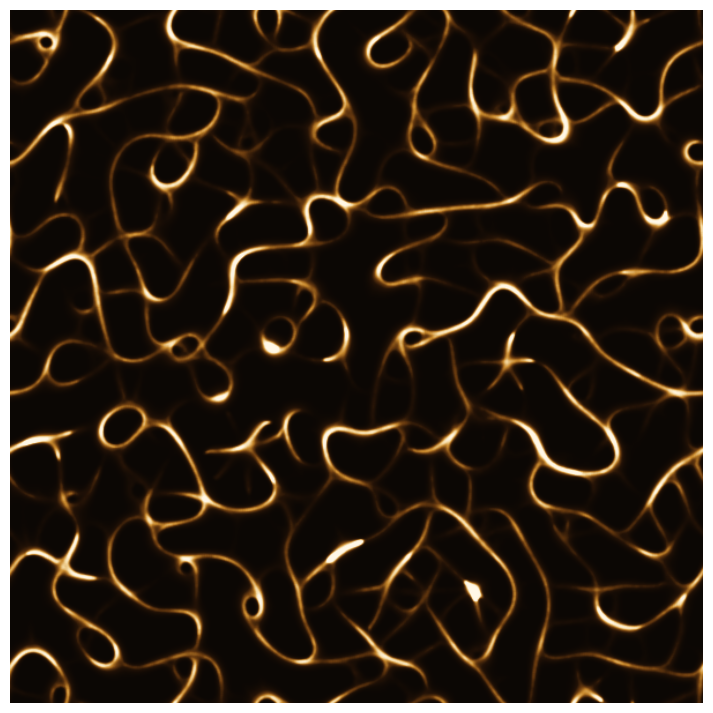

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch17_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(9, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the organism that plans railways

*Physarum polycephalum*, the many-headed slime mold (Schleimpilz), is a single giant cell with millions of nuclei, a bright yellow sprawl that forages across forest floors by extending a network of protoplasmic veins. It has no brain, no nervous system, no neurons. It also, demonstrably, solves routing problems. In 2000, Toshiyuki Nakagaki and colleagues showed the organism finding the shortest path through a maze between two food sources (*Nature* 407). In 2010, Atsushi Tero and the same group placed oat flakes on the positions of the cities around Tokyo, used light (which the organism avoids) to stand in for coastline and mountains, and let it forage: the network it settled on was comparable in efficiency, fault tolerance and cost to the actual Tokyo rail system (*Science* 327). The two studies earned two Ig Nobel Prizes, 2008 and 2010, the prize for research that makes people laugh and then think; rarely has it been so precisely aimed.

Artists arrived from two directions. The UK-based artist **Heather Barnett** has worked *with* the living organism since 2008 (*The Physarum Experiments*): she sets conditions, the slime mold draws, and the authorship question of chapter 20 gets a co-author with no nervous system. The other direction is ours: simulate the behavior. In 2010 **Jeff Jones** distilled it into a model of striking economy (*Artificial Life* 16), a swarm of particle agents that sense a shared trail field ahead of themselves, turn toward strength, move, and deposit more trail. That loop, sense, rotate, move, deposit, has become the standard reference model in creative coding, most visibly through the work of **Sage Jenson** (mxsage), whose monumental simulations extending Jones's model are among the most recognizable images in contemporary generative art; their widely shared technical writeup is in the further reading.

For this book, the chapter completes a set. Chapter 9 grew complexity on a *grid*, chapter 10 in a *field*, chapter 15 among *agents* that watch each other. Physarum couples agents *to* a field: the agents write it, the field steers them, and the coupling closes a feedback loop that neither has alone. Ecologists call communication through a modified environment **stigmergy**; it is how ant trails and termite cathedrals work. One honesty note before we start, in Jones's own words: this is an *approximation* of physarum-like network formation, not a biological simulation. No cytoplasm is modeled, only the logic of trails, and the logic turns out to be where the pictures live.

## The two halves of the machine

**The field.** A grid of numbers, the *trail* (chemoattractant, for the organism; for us, paint that behaves). Each tick it does two things you already know from chapter 10: it **diffuses** (each cell becomes the local average, one pass of blurring) and it **decays** (everything is multiplied by a factor just under 1, so yesterday's trail fades). Deposit, diffuse, decay; the field alone is chapter 10 in three lines:

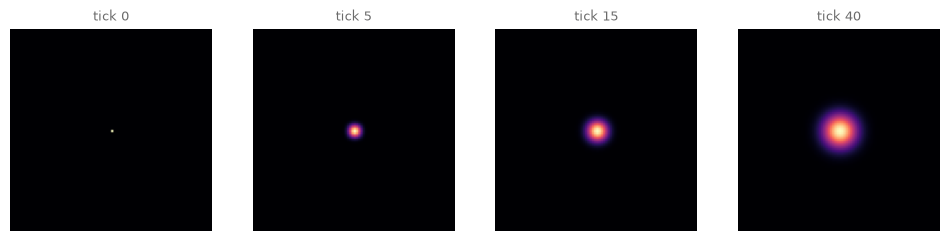

In [2]:
# the field alone: one deposit, then diffusion and decay do their work
import numpy as np
from scipy.ndimage import uniform_filter

trail = np.zeros((90, 90))
trail[45, 45] = 500.0                       # one big deposit in the middle

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
tick = 0
for ax, target in zip(axes, [0, 5, 15, 40]):
    while tick < target:
        trail = uniform_filter(trail, size=3, mode="wrap") * 0.9   # diffuse, decay
        tick += 1
    ax.imshow(trail, cmap="magma")
    ax.set_title(f"tick {target}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

The dot spreads and fades: the field is a *forgetful* memory, and the decay factor sets how long it holds a thought. (`uniform_filter` is the same local averaging chapter 10 built its Laplacian from, packaged; `mode="wrap"` joins the edges so our world is a torus with no walls.)

**Try it.** Change `0.9` to `0.8` and the memory shortens; at `0.99` the dot haunts the grid for hundreds of ticks.

**The agents.** Each agent is a position and a heading angle, chapter 15's state, minus the velocity vector (all agents walk at the same speed, one pixel per tick). What is new is the *sense* step. Three sensors ride ahead of each agent, at distance $d$, one straight ahead and one rotated $\pm\alpha$ to each side:

$$s_{\text{left}} = (x + d\cos(\theta - \alpha),\; y + d\sin(\theta - \alpha)), \qquad s_{\text{front}},\; s_{\text{right}} \text{ likewise.}$$

The agent reads the trail at all three points and turns, by a fixed angle, toward the strongest reading (straight if the front wins; and if the front reads *weakest* of the three, the agent is confused and flips a coin). Then it moves and deposits. Sense, rotate, move, deposit, forever:

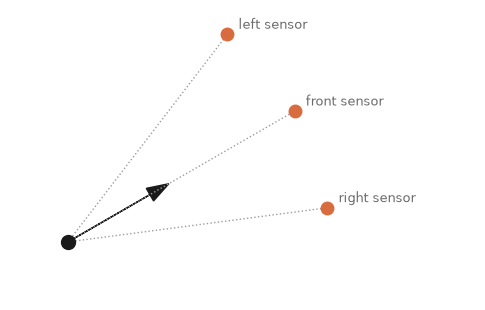

In [3]:
# one agent's anatomy: heading arrow, and the three sensors riding ahead
sensor_dist, sensor_angle = 9, np.deg2rad(22.5)
theta = np.deg2rad(30)

fig, ax = plt.subplots(figsize=(6, 4.4))
ax.arrow(0, 0, 4 * np.cos(theta), 4 * np.sin(theta), head_width=0.5,
         color="#1A1A1A", length_includes_head=True)
labels = ["left sensor", "front sensor", "right sensor"]
for offset, label in zip([sensor_angle, 0.0, -sensor_angle], labels):
    sx = sensor_dist * np.cos(theta + offset)
    sy = sensor_dist * np.sin(theta + offset)
    ax.plot([0, sx], [0, sy], ":", color="#9C9C9C", lw=1)
    ax.plot(sx, sy, "o", color="#D96C3F", markersize=9)
    ax.annotate(label, (sx, sy), textcoords="offset points", xytext=(8, 4),
                fontsize=9, color="#6B6B6B")
ax.plot(0, 0, "o", color="#1A1A1A", markersize=10)
ax.set_aspect("equal")
ax.set_xlim(-2, 14)
ax.set_ylim(-2, 8)
ax.axis("off")
plt.show()

## Blind agents first

Before the sensors earn their keep, the negative control: what does the swarm draw when nobody can sense anything? Thirty thousand agents, random headings with a random wobble, depositing as they go.

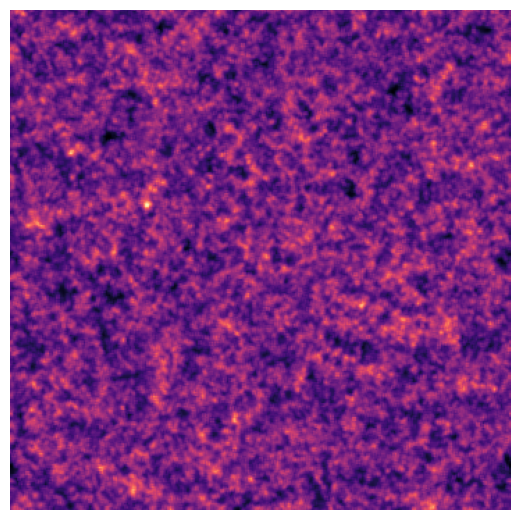

In [4]:
# the negative control: deposit without sensing is just noise with momentum
rng = np.random.default_rng(17)
size, n_agents = 360, 30000
x = rng.uniform(0, size, n_agents)
y = rng.uniform(0, size, n_agents)
heading = rng.uniform(0, 2 * np.pi, n_agents)
blind_trail = np.zeros((size, size))

for step in range(200):
    heading += rng.normal(0, 0.3, n_agents)       # wobble, but no sensing
    x = (x + np.cos(heading)) % size              # % size: walk off one edge,
    y = (y + np.sin(heading)) % size              #   reappear on the other
    np.add.at(blind_trail, (y.astype(int), x.astype(int)), 1.0)
    blind_trail = uniform_filter(blind_trail, size=3, mode="wrap") * 0.9

plt.figure(figsize=(6.5, 6.5))
plt.imshow(blind_trail, cmap="magma")
plt.axis("off")
plt.show()

Fuzz. Perfectly honest fuzz: thirty thousand chapter-1 random walks, politely fading. Remember this picture, because the only thing we add next is the ability to *smell*, and the difference is the whole chapter.

(One numpy honesty note: the deposit line uses `np.add.at(trail, (rows, cols), 1.0)` instead of `trail[rows, cols] += 1.0`, because when two agents stand on the same cell, plain `+=` writes the cell twice and keeps only one deposit; `np.add.at` adds every single one.)

## The engine

Now the full loop, as one function. Beyond the sense-rotate-move-deposit cycle it takes an optional `start` (agent starting positions; the default is everywhere at random) and an optional `food` (grid cells that receive a free trail bonus every tick; exercise (b) will feed it), and it can photograph the field at requested `snapshots`. At about thirty lines it is the second engine in two chapters; the pattern of chapter 16 repeats deliberately, because this *is* how simulation code is shaped.

In [5]:
# the Jones model: sense the field ahead, turn toward strength, walk, deposit
def physarum(size=360, n_agents=30000, n_steps=400, sensor_dist=9,
             sensor_angle=np.deg2rad(22.5), turn=np.deg2rad(45), decay=0.90,
             seed=17, start=None, food=None, snapshots=()):
    rng = np.random.default_rng(seed)
    if start is None:
        x = rng.uniform(0, size, n_agents)
        y = rng.uniform(0, size, n_agents)
    else:
        x, y = start[0].copy(), start[1].copy()
    heading = rng.uniform(0, 2 * np.pi, len(x))
    trail = np.zeros((size, size))
    shots = {}
    for step in range(n_steps):
        readings = []
        for offset in (-sensor_angle, 0.0, sensor_angle):
            sx = (x + sensor_dist * np.cos(heading + offset)).astype(int) % size
            sy = (y + sensor_dist * np.sin(heading + offset)).astype(int) % size
            readings.append(trail[sy, sx])
        left, front, right = readings
        confused = (front < left) & (front < right)     # weakest ahead: coin flip
        go_left = (left > front) & (left >= right) & ~confused
        go_right = (right > front) & (right > left) & ~confused
        coin = rng.random(len(x)) < 0.5
        heading = (heading - turn * (go_left | (confused & coin))
                           + turn * (go_right | (confused & ~coin)))
        x = (x + np.cos(heading)) % size
        y = (y + np.sin(heading)) % size
        np.add.at(trail, (y.astype(int), x.astype(int)), 1.0)
        if food is not None:
            trail[food] += 2.0                          # standing invitation
        trail = uniform_filter(trail, size=3, mode="wrap") * decay
        if step + 1 in snapshots:
            shots[step + 1] = trail.copy()
    return trail, shots

(The steering lines multiply angles by booleans: `go_left` is `True` or `False` per agent, worth 1 or 0 in arithmetic, so each agent turns by `turn`, `-turn`, or nothing, all thirty thousand at once with no `if`.) Run it, and watch the field over time:

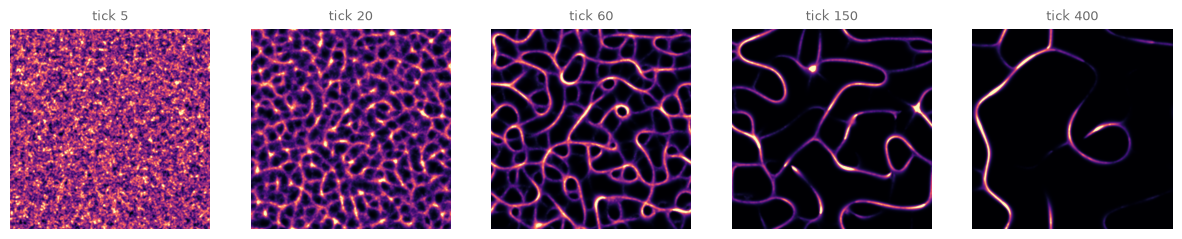

In [6]:
# the wow cell: a network condenses out of noise, then edits itself
trail, shots = physarum(n_steps=400, snapshots=(5, 20, 60, 150, 400))

fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
for ax, (when, field) in zip(axes, shots.items()):
    # vmax from a percentile: the brightest few pixels would otherwise crush the rest
    ax.imshow(field, cmap="magma", vmax=np.percentile(field, 99.5))
    ax.set_title(f"tick {when}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

Read it left to right, and compare with the blind fuzz. By tick 20 the fuzz has curdled into filaments; by tick 60 the filaments have joined into a dense web; and then something stranger happens: the network starts *editing itself*. Redundant threads lose traffic, fade below the sensors' notice, and vanish; junctions merge; loops simplify. By tick 400 the swarm maintains a few confident boulevards. That editing is not our code, there is no line that prunes; it is the feedback loop finding that two parallel roads cannot both keep their scent. Tero's slime mold did exactly this to the Tokyo network, which is why its final map was *efficient* and not merely connected. The price of efficiency is visible too: the late network serves far fewer places. Every stage of this filmstrip is a defensible artwork, and *when to stop* is the physarum artist's first authored decision.

**Try it.** Re-run the wow cell with `sensor_dist=18`: the whole anatomy doubles its wavelength, coarser veins, wider cells, because agents plan further ahead. Then try `decay=0.97` and watch the network drown in its own memory.

## Four anatomies

The dials interact, but four presets span the space well:

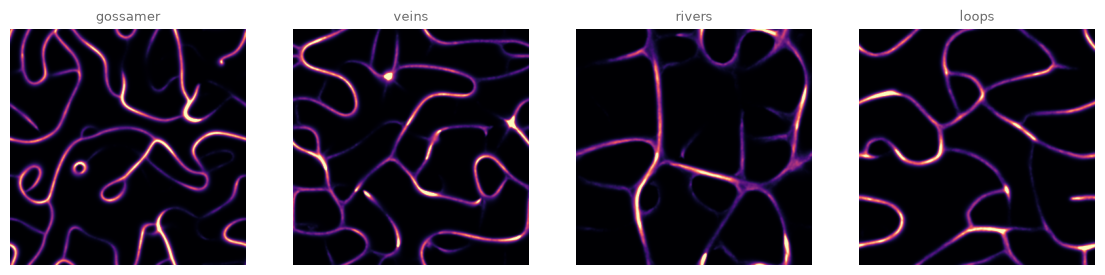

In [7]:
# four presets: the same swarm, four anatomies
presets = [
    ("gossamer", dict(sensor_dist=4, decay=0.92, n_steps=200)),
    ("veins", dict(sensor_dist=9, n_steps=150)),
    ("rivers", dict(sensor_dist=18, n_steps=300)),
    ("loops", dict(sensor_angle=np.deg2rad(60), turn=np.deg2rad(75), n_steps=300)),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (name, kwargs) in zip(axes, presets):
    field, _ = physarum(**kwargs)
    ax.imshow(field, cmap="magma", vmax=np.percentile(field, 99.5))
    ax.set_title(name, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** Gossamer is all capillaries, rivers is all highways, and the two differ in a single number: how far ahead an agent smells. The loops preset turns hard and often, so its roads curl back on themselves. Which anatomy feels most *alive* to you, and which most *designed*? (Most people say the middle two; it is worth asking what that implies about the scales at which we recognize life.)

## The swarm as portraitist (bonus)

The agents' starting positions are ours to choose, and chapter 12 taught us how to turn an image into positions: rejection sampling by darkness. Seed the swarm where the Vermeer is dark, stop early, before the editing phase erases the evidence, and the network is a drawing *of* the painting, in the medium of traffic.

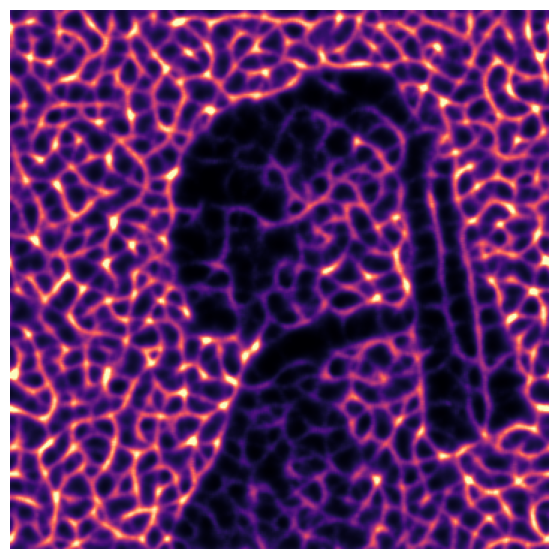

In [8]:
# seed the swarm by image darkness (chapter 12's rejection sampling), stop early
from PIL import Image

girl = Image.open("../assets/images/vermeer_pearl_earring.jpg")
darkness = 1 - np.asarray(girl.convert("L").resize((360, 360))) / 255

placed_x, placed_y = [], []
while len(placed_x) < 120000:
    cx, cy = rng.uniform(0, 360, 50000), rng.uniform(0, 360, 50000)
    keep = rng.random(50000) < darkness[cy.astype(int), cx.astype(int)]**1.5
    placed_x.extend(cx[keep])
    placed_y.extend(cy[keep])
start = (np.array(placed_x[:120000]), np.array(placed_y[:120000]))

portrait, _ = physarum(n_steps=15, start=start, sensor_dist=6)

plt.figure(figsize=(7, 7))
plt.imshow(portrait, cmap="magma", vmax=np.percentile(portrait, 99.5))
plt.axis("off")
plt.show()

Fifteen ticks: long enough for the web to form, short enough that it still lives where it was born. The girl exists in this image only as a *difference in traffic density*, which is, come to think of it, also how chapter 11's heatmaps drew attention and chapter 12's stipples drew shadow: one more member of the book's family of images made of where-things-are.

## Export your artwork

Choose a preset (or an anatomy of your own), a moment to stop, and a palette: the render below dresses the trail field in a custom colormap exactly as chapter 16 dressed its frost. Replace `yourname` and run.

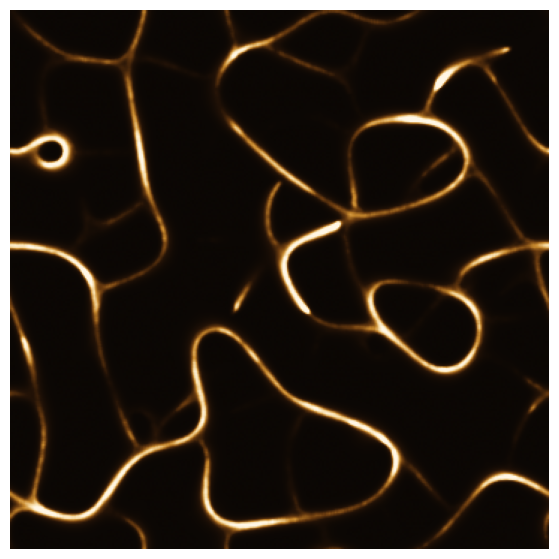

saved: assets/outputs/ch17_yourname.png


In [9]:
# save YOUR artwork: grow a network, dress it, replace 'yourname'
import sys
sys.path.append("..")
from agap.helpers import save_artwork, show
from matplotlib.colors import LinearSegmentedColormap

def trail_image(field, colors, gamma=1.0):
    cmap = LinearSegmentedColormap.from_list("trail", colors)
    bright = np.clip(field / np.percentile(field, 99.5), 0, 1)
    return cmap(bright**gamma)[..., :3]

AMBER = ["#0B0704", "#241307", "#6B3C10", "#C98A2E", "#F5D9A0", "#FFF7E6"]

my_field, _ = physarum(sensor_dist=9, n_steps=150, seed=7)
my_artwork = np.kron(trail_image(my_field, AMBER), np.ones((6, 6, 1)))
show(my_artwork)
saved_path = save_artwork(my_artwork, "yourname", chapter=17)

## Exercises

**(a) Parameter exploration: where veins become cells.** Sweep the sensor angle: 5, 15, 22.5, 40, 60 degrees (leave everything else at the defaults, 150 ticks). Somewhere in that sweep the anatomy changes character, from directed veins to rounder, cell-like enclosures. Find the angle where it happens for you, and offer a one-sentence mechanical explanation (what does a wide-angled agent know about the world that a narrow-angled one does not?).

**(b) Code modification: feed it Tokyo.** The engine's `food` argument accepts grid cells that receive a trail bonus every tick. Build eight food dots arranged in a ring (chapter 3's polygon trigonometry, reporting for duty), run for 500 ticks, and watch the swarm discover and *connect* them: the oat-flake experiment, in silicon. Where do the connecting roads run, along the ring, or through the middle?

<details><summary>Solution</summary>

```python
angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
food_rows = np.round(180 + 110 * np.sin(angles)).astype(int)
food_cols = np.round(180 + 110 * np.cos(angles)).astype(int)
fed, _ = physarum(n_steps=500, food=(food_rows, food_cols))
plt.figure(figsize=(7, 7))
plt.imshow(fed, cmap="magma", vmax=np.percentile(fed, 99.5))
plt.axis("off")
plt.show()
```

(`endpoint=False` stops `linspace` one step short of $2\pi$, so the eighth dot does not land on the first.) The stations glow because the bonus keeps them fragrant, and the network anchors itself to them: mostly ring roads between neighbors, with occasional diagonals when the simulation found a shortcut worth its maintenance cost. Re-run with a different `seed` and the *topology* changes while the stations stand still: same cities, different railway, which is precisely the design space Tero's paper measured the organism against.
</details>

**(c) Creative challenge: the network wears your colors.** `trail_image` takes any color list, so `PALETTES["viridis"]`, an extracted chapter-5 palette, or a two-color list like `["#F2EFE9", "#1B4B9B"]` (a network drawn in ink on paper, veins dark instead of glowing) each produce a different creature from the same field. Alternatively, combine the bonus and exercise (b): seed the swarm with one artwork's darkness and feed it another artwork's bright spots. Name the result honestly and bring it to the gallery.

## Further reading

- Heather Barnett, "What humans can learn from semi-intelligent slime" (TED, 2014, free online): twelve minutes with the living organism, by the artist who collaborates with it.
- Sage Jenson, "physarum" (sagejenson.com/physarum, free): the illustrated technical writeup behind their celebrated simulations; the direct bridge from this chapter to contemporary practice.
- Jeff Jones, "Characteristics of Pattern Formation and Evolution in Approximations of Physarum Transport Networks", *Artificial Life* 16/2 (2010): the paper this chapter implements; a free PDF is available via the UWE Bristol research repository.
- Steven Johnson, *Emergence* (Scribner, 2001): a book-length version of this book's favorite theme, and it opens, of course, with the slime mold.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: a larger world, four hundred thousand agents, stopped young at tick 90 while the web is at its densest, dressed in amber and enlarged with `np.kron`. About ten seconds. It runs automatically with *Restart & Run All*.

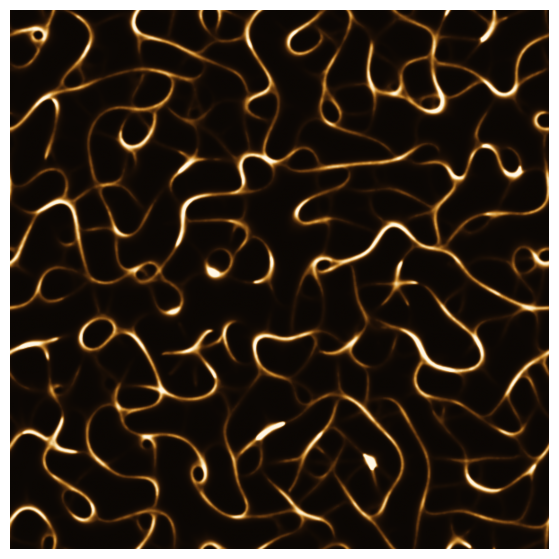

saved: assets/outputs/ch17_showpiece.png


In [10]:
# regenerate this chapter's showpiece: the young network, in amber
showpiece_field, _ = physarum(size=600, n_agents=400000, n_steps=90, seed=17)
showpiece = np.kron(trail_image(showpiece_field, AMBER), np.ones((4, 4, 1)))
show(showpiece)
saved_path = save_artwork(showpiece, "showpiece", chapter=17)